In [19]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import config
import pipeline
import pipeline_detail
import concordance_detail
importlib.reload(config)
importlib.reload(pipeline)
importlib.reload(pipeline_detail)
importlib.reload(concordance_detail)

# ── Display active parameters ─────────────────────────────────────────────────
# Edit config.py to change any of these — no changes to this notebook needed.
print("=" * 60)
print("DETAIL (402-COMMODITY) TARIFF PCE PIPELINE")
print("=" * 60)
rows = [
    ("Detail IO year",           config.DETAIL_IO_YEAR),
    ("Summary IO year",          config.IO_YEAR),
    ("Leontief source",          "BEA pre-computed CxC TR (detail)"),
    ("Supply table",             config.DETAIL_SUPPLY_FILE),
    ("CxC Total Requirements",   config.DETAIL_CXC_TR_FILE),
    ("PCE bridge (detail)",      config.DETAIL_PCE_BRIDGE_FILE),
    ("NAICS concordance",        config.DETAIL_CONCORDANCE_FILE),
    ("Tariff baseline year",     config.TARIFF_BASELINE_YEAR),
    ("Tariff current month",     config.TARIFF_CURRENT_MONTH),
    ("Markup assumption",        config.MARKUP_ASSUMPTION),
    ("Inflation measure",        config.INFLATION_MEASURE),
    ("Counterfactual baseline",  config.COUNTERFACTUAL_BASELINE_MONTH),
    ("Excess inflation window",  f"{config.EXCESS_BASELINE_START}\u2013{config.EXCESS_BASELINE_END}"),
    ("Excess current window",    f"{config.EXCESS_CURRENT_START_MONTH} \u2192 {config.EXCESS_CURRENT_END_MONTH}"),
    ("Core goods categories",    len(config.CORE_GOODS_CATEGORIES)),
]
for label, val in rows:
    print(f"  {label:<30} {val}")
print("=" * 60)

DETAIL (402-COMMODITY) TARIFF PCE PIPELINE
  Detail IO year                 2017
  Summary IO year                2024
  Leontief source                BEA pre-computed CxC TR (detail)
  Supply table                   c:\github\tariffs-inflation\code\..\data/io_detail/Supply_2017_DET.xlsx
  CxC Total Requirements         c:\github\tariffs-inflation\code\..\data/io_detail/CxC_TR_2017_PRO_DET.xlsx
  PCE bridge (detail)            c:\github\tariffs-inflation\code\..\data/io_detail/PCEBridge_Detail.xlsx
  NAICS concordance              c:\github\tariffs-inflation\code\..\data/stuff/BEA-Industry-and-Commodity-Codes-and-NAICS-Concordance.xlsx
  Tariff baseline year           2024
  Tariff current month           2025-12
  Markup assumption              constant_dollar
  Inflation measure              core_pce
  Counterfactual baseline        2024-12
  Excess inflation window        2015–2019
  Excess current window          2024-12 → 2025-12
  Core goods categories          27


In [20]:
# ── Step 1: Direct import shares (m_i = imports / total supply) ──────────────
# 402-commodity detail Supply table (Supply_2017_DET.xlsx)
# m_i = MCIF(i) / T013(i)

import_shares = pipeline_detail.detail_step1_import_shares(
    config.DETAIL_SUPPLY_FILE, config.DETAIL_IO_YEAR
)

print(f"Commodities: {len(import_shares)}")
print(f"Import share range: "
      f"{import_shares['import_share'].min():.4f} \u2013 {import_shares['import_share'].max():.4f}")
print(f"\nTop 15 by direct import share:")
print(
    import_shares.nlargest(15, 'import_share')
    [['bea_detail', 'bea_detail_desc', 'import_share']]
    .to_string(index=False)
)

Commodities: 402
Import share range: -0.0076 – 1.0000

Top 15 by direct import share:
bea_detail                                                          bea_detail_desc  import_share
    S00402                                                Used and secondhand goods          1.00
    S00300                                                    Noncomparable imports          1.00
    334300                                  Audio and video equipment manufacturing          0.90
    339930                                        Doll, toy, and game manufacturing          0.90
    316000                                 Leather and allied product manufacturing          0.89
    315000                                                    Apparel manufacturing          0.88
    334111                                        Electronic computer manufacturing          0.88
    334118 Computer terminals and other computer peripheral equipment manufacturing          0.82
    334220                      

In [21]:
# ── Steps 2\u20133: Pre-computed Leontief inverse (L) ────────────────────────────
# BEA's Commodity-by-Commodity Total Requirements (CxC_TR_2017_PRO_DET.xlsx)
# This is the proper (I - B\u00b7D)^{-1} using BEA's Make/Use framework.
# No matrix inversion needed \u2014 BEA computed it.

commodities, L = pipeline_detail.detail_step2_3_leontief(
    config.DETAIL_CXC_TR_FILE, config.DETAIL_IO_YEAR
)

print(f"Commodities: {len(commodities)}")
print(f"L matrix shape:                  {L.shape}")
print(f"Leontief diagonal mean (> 1):    {np.diag(L).mean():.4f}")
print(f"Leontief diagonal range:         [{np.diag(L).min():.4f}, {np.diag(L).max():.4f}]")
print(f"L min value (should be \u2265 0):     {L.min():.6f}")
print(f"L max value:                     {L.max():.4f}")

Detail Leontief: 402 commodities, diagonal range [1.000, 1.745]
Commodities: 402
L matrix shape:                  (402, 402)
Leontief diagonal mean (> 1):    1.0512
Leontief diagonal range:         [1.0000, 1.7453]
L min value (should be ≥ 0):     -0.002754
L max value:                     1.7453


In [22]:
# ── Validation: detail (402) vs summary (71) Leontief ────────────────────────
# The detail L captures within-industry heterogeneity that the summary level
# aggregates away.  Key benefit: motor vehicles at detail level separates
# automobile mfg (high import share) from light trucks (lower).

summary_industries, _, summary_L = pipeline.step2_3_leontief(
    config.IO_YEAR, config.BEA_KEY, config.LEONTIEF_SOURCE
)

print(f"Summary Leontief: {summary_L.shape[0]} industries \u00d7 {summary_L.shape[1]}")
print(f"Detail Leontief:  {L.shape[0]} commodities \u00d7 {L.shape[1]}")
print(f"Granularity gain: {L.shape[0] / summary_L.shape[0]:.1f}\u00d7")
print(f"\nSummary diagonal: mean={np.diag(summary_L).mean():.4f}, "
      f"range=[{np.diag(summary_L).min():.4f}, {np.diag(summary_L).max():.4f}]")
print(f"Detail diagonal:  mean={np.diag(L).mean():.4f}, "
      f"range=[{np.diag(L).min():.4f}, {np.diag(L).max():.4f}]")
print(f"\nNote: Summary uses {config.IO_YEAR} tables (API); "
      f"detail uses {config.DETAIL_IO_YEAR} tables (Excel downloads).")
print(f"The detail L is BEA's pre-computed CxC Total Requirements; the summary L")
print(f"is {'BEA pre-computed (Table 59)' if config.LEONTIEF_SOURCE == 'bea' else 'computed from (I - A)^{-1} via Use Table 259'}.")

Leontief source: BEA pre-computed Total Requirements (TableID 59)
Summary Leontief: 68 industries × 68
Detail Leontief:  402 commodities × 402
Granularity gain: 5.9×

Summary diagonal: mean=1.0916, range=[1.0000, 1.5990]
Detail diagonal:  mean=1.0512, range=[1.0000, 1.7453]

Note: Summary uses 2024 tables (API); detail uses 2017 tables (Excel downloads).
The detail L is BEA's pre-computed CxC Total Requirements; the summary L
is BEA pre-computed (Table 59).


In [23]:
# ── Step 4: Total import content (m_total = m' L) ────────────────────────────
# Supply-chain amplification at 402-commodity detail.

m_vec, m_total = pipeline_detail.detail_step4_total_import_content(
    import_shares, commodities, L
)

print(f"Direct import shares mean:   {m_vec.mean():.4f}")
print(f"Total import content mean:   {m_total.mean():.4f}")
print(f"Supply-chain amplification:  {m_total.mean() / m_vec.mean():.2f}\u00d7")

print(f"\nTop 15 by total import content:")
m_df = pd.DataFrame({
    'bea_detail': commodities,
    'direct': m_vec,
    'total': m_total,
}).merge(import_shares[['bea_detail', 'bea_detail_desc']], on='bea_detail', how='left')
print(
    m_df.nlargest(15, 'total')
    [['bea_detail', 'bea_detail_desc', 'direct', 'total']]
    .to_string(index=False, float_format=lambda x: f"{x:.4f}")
)

Direct import shares mean:   0.1535
Total import content mean:   0.2803
Supply-chain amplification:  1.83×

Top 15 by total import content:
bea_detail                                                          bea_detail_desc  direct  total
    316000                                 Leather and allied product manufacturing  0.8867 1.0319
    334300                                  Audio and video equipment manufacturing  0.9030 1.0208
    334118 Computer terminals and other computer peripheral equipment manufacturing  0.8233 1.0102
    337122                    Nonupholstered wood household furniture manufacturing  0.7602 1.0070
    S00402                                                Used and secondhand goods  1.0000 1.0000
    S00300                                                    Noncomparable imports  1.0000 1.0000
    339930                                        Doll, toy, and game manufacturing  0.8980 0.9983
    315000                                                    Appare

In [24]:
# ── Step 5: \u0394\u03c4 = \u03c4_current \u2212 \u03c4_baseline per BEA detail commodity ────────────────────
# Uses longest-prefix NAICS6 \u2192 BEA detail concordance.
# Baseline: annual average over all 12 months of config.TARIFF_BASELINE_YEAR
# Current:  single month config.TARIFF_CURRENT_MONTH

delta_tariff_df = pipeline_detail.detail_step5_delta_tariff(
    config.IMPORTS_FILE,
    config.TARIFF_BASELINE_YEAR,
    config.TARIFF_CURRENT_MONTH,
    config.DETAIL_CONCORDANCE_FILE,
)

print(f"BEA detail commodities with tariff data: {len(delta_tariff_df)}")
print(f"\nTop 15 by tariff increase (\u0394\u03c4):")
print(
    delta_tariff_df.nlargest(15, 'delta_tariff')
    [['bea_detail', 'bea_detail_desc', 'tau_base', 'tau', 'delta_tariff']]
    .to_string(index=False, float_format=lambda x: f"{x:.4f}")
)

Detail concordance: 374/388 NAICS6 codes mapped to BEA detail commodities
  Out of scope (services/unmapped): 14 codes
  BEA detail commodities covered: 235

Import value coverage: 84.4% of total import value mapped to BEA detail commodities

Import value coverage: 85.3% of total import value mapped to BEA detail commodities
BEA detail commodities with tariff data: 235

Top 15 by tariff increase (Δτ):
bea_detail                                            bea_detail_desc  tau_base    tau  delta_tariff
    33131B     Aluminum product manufacturing from purchased aluminum    0.0598 0.5074        0.4476
    332996             Fabricated pipe and pipe fitting manufacturing    0.0702 0.4884        0.4182
    331313           Alumina refining and primary aluminum production    0.0109 0.4289        0.4180
    332720      Turned product and screw, nut, and bolt manufacturing    0.0653 0.4586        0.3933
    331200           Steel product manufacturing from purchased steel    0.0648 0.4229    

In [25]:
# ── Detail vs summary: tariff rates ──────────────────────────────────────────
# Compare how the same trade data maps to different BEA aggregation levels.
# At summary level, many detail commodities get pooled into one industry,
# averaging away within-industry tariff heterogeneity.

summary_delta = pipeline.step5_delta_tariff(
    config.IMPORTS_FILE,
    config.TARIFF_BASELINE_YEAR,
    config.TARIFF_CURRENT_MONTH,
    concordance_method=config.CONCORDANCE_METHOD,
    bea_concordance_file=(config.BEA_CONCORDANCE_FILE or None),
    fallback_to_manual_unmapped=config.CONCORDANCE_FALLBACK_TO_MANUAL_UNMAPPED,
)

print("Detail vs Summary: tariff rates for key industries")
print("=" * 90)
comparisons = {
    "Motor vehicles (3361MV)": ("3361MV", [c for c in delta_tariff_df['bea_detail'] if str(c).startswith('3361')]),
    "Furniture (337)":         ("337",    [c for c in delta_tariff_df['bea_detail'] if str(c).startswith('337')]),
    "Apparel (315AL)":         ("315AL",  [c for c in delta_tariff_df['bea_detail'] if str(c).startswith(('3152', '3159'))]),
    "Comp & elec (334)":       ("334",    [c for c in delta_tariff_df['bea_detail'] if str(c).startswith('334')]),
    "Machinery (333)":         ("333",    [c for c in delta_tariff_df['bea_detail'] if str(c).startswith('333')]),
}

for label, (s_code, d_codes) in comparisons.items():
    s_row = summary_delta[summary_delta['bea_io'] == s_code]
    s_dt = s_row['delta_tariff'].values[0] if len(s_row) > 0 else float('nan')
    print(f"\n{label}: summary \u0394\u03c4 = {s_dt:.1%}")
    detail_sub = delta_tariff_df[delta_tariff_df['bea_detail'].isin(d_codes)]
    if len(detail_sub) > 0:
        for _, r in detail_sub.iterrows():
            print(f"  {r['bea_detail']} {r['bea_detail_desc'][:45]:<45s}  "
                  f"\u0394\u03c4 = {r['delta_tariff']:.1%}  "
                  f"(base={r['tau_base']:.1%}, curr={r['tau']:.1%})")

Concordance built (bea_file): 383/388 NAICS6 codes mapped to BEA IO industries
  Manual fallback used for 9 unmapped NAICS6 codes
  Out of scope (services/unmapped): 5 codes
  BEA IO industries covered: 23

Import value coverage: 94.6% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining

Import value coverage: 93.5% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining
Detail vs Summary: tariff rates for key industries

Motor vehicles (3361MV): summary Δτ = 12.5%
  336120 Heavy duty truck manufacturing                 Δτ = 15.7%  (base=0.3%, curr=16.0%)

Furniture (337): summary Δτ = 18.3%
  337110 Wood kitchen cabinet and countertop manufactu  Δτ = 20.9%  (base=0.2%, curr=21.1%)
  337121 Upholstered household furniture manufacturing  Δτ 

In [26]:
# ── PCE Bridge + Step 6: Predicted tariff effect per PCE category ────────────
# Detail PCE bridge maps 402 commodities \u2192 ~212 PCE categories.
# Markup assumption (config.MARKUP_ASSUMPTION):
#   "constant_dollar"  \u2192 numerator weighted by producers' value (conservative)
#   "constant_percent" \u2192 numerator weighted by purchasers' value (larger effect)
#
# After computing detail-level effects, we aggregate to the 27 summary-level
# core goods categories used in config.CORE_GOODS_CATEGORIES.

pce_bridge_detail = pipeline_detail.load_detail_pce_bridge(
    config.DETAIL_PCE_BRIDGE_FILE, config.DETAIL_IO_YEAR
)

pce_effect_detail = pipeline_detail.detail_step6_pce_effect(
    commodities     = commodities,
    m_vec           = m_vec,
    L               = L,
    delta_tariff_df = delta_tariff_df,
    pce_bridge      = pce_bridge_detail,
    markup          = config.MARKUP_ASSUMPTION,
)

print(f"Markup assumption: {config.MARKUP_ASSUMPTION}")
print(f"Detail PCE categories: {len(pce_effect_detail)}")
print(f"\nTop 15 detail PCE categories by predicted tariff effect:")
print(
    pce_effect_detail.head(15)[['PCE_category', 'predicted_effect']]
    .to_string(index=False, float_format=lambda x: f"{x:.4f}")
)

# ── Aggregate to summary-level 27 core goods categories ──────────────────────
pce_effect_df = pipeline_detail.aggregate_to_summary_pce(pce_effect_detail)

print(f"\n\nSummary-level core goods categories: {len(pce_effect_df)}")
print(f"\nAll {len(pce_effect_df)} categories by predicted tariff effect:")
print(
    pce_effect_df[['PCE_category', 'predicted_effect']]
    .to_string(index=False, float_format=lambda x: f"{x:.4f}")
)

# Weighted-average effect on core goods \u2014 carried forward to counterfactual cells
core = pce_effect_df.query('PCE_category in @config.CORE_GOODS_CATEGORIES')
core_effect = (
    (core['predicted_effect'] * core['purchasers_value_total']).sum()
    / core['purchasers_value_total'].sum()
)
print(f"\nWeighted avg predicted effect \u2014 core goods: {core_effect:.2%}")

Markup assumption: constant_dollar
Detail PCE categories: 212

Top 15 detail PCE categories by predicted tariff effect:
                                  PCE_category  predicted_effect
Standard clothing issued to military personnel            0.1046
         Electric appliances for personal care            0.0816
           Small electric household appliances            0.0809
            Luggage and similar personal items            0.0634
                      Men's and boys' clothing            0.0594
                      Shoes and other footwear            0.0554
                   Women's and girls' clothing            0.0509
                                   Televisions            0.0508
                      Games, toys, and hobbies            0.0478
                                   Motorcycles            0.0471
                              Fish and seafood            0.0460
                      Bicycles and accessories            0.0428
                                   

c:\github\tariffs-inflation\code\pipeline_detail.py:371: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapped["effect_x_puv"] = mapped["predicted_effect"] * mapped["purchasers_value_total"]


In [27]:
# ── Detail vs summary: PCE effects comparison ────────────────────────────────
# Run the full summary pipeline and compare category-level predicted effects.

summary_import_shares = pipeline.step1_import_shares(config.IO_YEAR, config.BEA_KEY)
summary_m_vec, summary_m_total = pipeline.step4_total_import_content(
    summary_import_shares, summary_industries, summary_L
)
pce_bridge_summary = pipeline.load_pce_bridge(config.IO_YEAR, config.BEA_KEY)
pce_effect_summary = pipeline.step6_pce_effect(
    industries      = summary_industries,
    m_vec           = summary_m_vec,
    L               = summary_L,
    delta_tariff_df = summary_delta,
    pce_bridge      = pce_bridge_summary,
    markup          = config.MARKUP_ASSUMPTION,
)

# Compare at category level
comp = pce_effect_df[['PCE_category', 'predicted_effect']].merge(
    pce_effect_summary[['PCE_category', 'predicted_effect']],
    on='PCE_category', how='outer', suffixes=('_detail', '_summary'),
)
comp['diff_pp'] = (comp['predicted_effect_detail'] - comp['predicted_effect_summary']) * 100
comp = comp.sort_values('diff_pp', key=abs, ascending=False)

core_comp = comp[comp['PCE_category'].isin(config.CORE_GOODS_CATEGORIES)].copy()
print("Detail vs Summary: predicted PCE effects (core goods categories)")
print("=" * 100)
print(
    core_comp[['PCE_category', 'predicted_effect_detail', 'predicted_effect_summary', 'diff_pp']]
    .to_string(index=False, float_format=lambda x: f"{x:.4f}")
)

core_s = pce_effect_summary.query('PCE_category in @config.CORE_GOODS_CATEGORIES')
core_effect_summary = (
    (core_s['predicted_effect'] * core_s['purchasers_value_total']).sum()
    / core_s['purchasers_value_total'].sum()
)
print(f"\nAggregate core goods weighted effect:")
print(f"  Detail ({config.DETAIL_IO_YEAR}):  {core_effect:.2%}")
print(f"  Summary ({config.IO_YEAR}): {core_effect_summary:.2%}")
print(f"  Difference:      {(core_effect - core_effect_summary) * 100:+.2f} pp")

Detail vs Summary: predicted PCE effects (core goods categories)
                                                              PCE_category  predicted_effect_detail  predicted_effect_summary  diff_pp
                                                        New motor vehicles                   0.0202                    0.0413  -2.1098
                                                        Recreational items                   0.0247                    0.0107   1.3994
                                       Motor vehicle parts and accessories                   0.0305                    0.0212   0.9255
                              Glassware, tableware, and household utensils                   0.0349                    0.0260   0.8863
                                          Children's and infants' clothing                   0.0267                    0.0182   0.8422
Video, audio, photographic, and information processing equipment and media                   0.0138                    0.0055

In [28]:
# ── Worked example: trace motor vehicles through detail pipeline ─────────────
# Shows every step for automobile manufacturing (336111) \u2014 the commodity where
# detail vs summary disaggregation matters most.

TRACE_CODE = "336111"

trace_row = import_shares[import_shares['bea_detail'] == TRACE_CODE].iloc[0]
idx = list(commodities).index(TRACE_CODE)
tariff_row = delta_tariff_df[delta_tariff_df['bea_detail'] == TRACE_CODE]

print("\u2500" * 70)
print(f"  COMMODITY TRACE  \u00b7  {TRACE_CODE}  \u2014  {trace_row['bea_detail_desc']}")
print("\u2500" * 70)

print(f"\nStep 1  \u2014  Direct import share  (m_i = imports / total supply)")
print(f"  imports       = {trace_row['imports']:>15,.0f}  ($M)")
print(f"  total supply  = {trace_row['total_supply']:>15,.0f}  ($M)")
print(f"  m_i           = {trace_row['import_share']:>15.1%}")

print(f"\nStep 4  \u2014  Total import content via Leontief  (m\u0303_j = m\u2032 L)")
print(f"  direct m_i     = {m_vec[idx]:>15.1%}  (imports at the border)")
print(f"  total m\u0303_j      = {m_total[idx]:>15.1%}  (direct + all upstream tiers)")
indirect = m_total[idx] - m_vec[idx]
print(f"  indirect share = {indirect:>15.1%}  (embedded in domestic inputs)")
if m_vec[idx] > 0:
    print(f"  amplification  = {m_total[idx] / m_vec[idx]:>14.2f}\u00d7")

if len(tariff_row) > 0:
    tr = tariff_row.iloc[0]
    print(f"\nStep 5  \u2014  Import tariff change  (\u0394\u03c4 = \u03c4_current \u2212 \u03c4_baseline)")
    print(f"  \u03c4_baseline  = {tr['tau_base']:>15.1%}")
    print(f"  \u03c4_current   = {tr['tau']:>15.1%}")
    print(f"  \u0394\u03c4          = {tr['delta_tariff']:>+14.1%}")

# PCE bridge entries for this commodity
bridge_rows = pce_bridge_detail[pce_bridge_detail['commodity_code'] == TRACE_CODE]
if len(bridge_rows) > 0:
    print(f"\nStep 6  \u2014  PCE Bridge  ({TRACE_CODE} \u2192 PCE consumer categories)")
    print(f"  {'PCE category':<50s}  {'Prod ($M)':>12s}  {'Purch ($M)':>12s}")
    for _, br in bridge_rows.iterrows():
        print(f"  {br['PCE_category'][:50]:<50s}  "
              f"{br['producers_value']:>12,.0f}  {br['purchasers_value']:>12,.0f}")

# Compare to summary
print(f"\n{'\u2500' * 70}")
print(f"  COMPARISON: Summary pipeline (3361MV aggregated)")
print(f"{'\u2500' * 70}")
s_idx = list(summary_industries).index('3361MV') if '3361MV' in summary_industries else None
if s_idx is not None:
    print(f"  Summary direct import share:  {summary_m_vec[s_idx]:.1%}")
    print(f"  Summary total import content: {summary_m_total[s_idx]:.1%}")
    print(f"  Detail  direct import share:  {m_vec[idx]:.1%}  ({TRACE_CODE} only)")
    print(f"  Detail  total import content: {m_total[idx]:.1%}  ({TRACE_CODE} only)")
    print(f"\n  The summary pipeline lumps all motor vehicle sub-industries together,")
    print(f"  producing a single import content number. The detail pipeline separates")
    print(f"  auto mfg (high import share) from light trucks and heavy trucks.")

──────────────────────────────────────────────────────────────────────
  COMMODITY TRACE  ·  336111  —  Automobile manufacturing
──────────────────────────────────────────────────────────────────────

Step 1  —  Direct import share  (m_i = imports / total supply)
  imports       =          66,068  ($M)
  total supply  =          98,826  ($M)
  m_i           =           66.9%

Step 4  —  Total import content via Leontief  (m̃_j = m′ L)
  direct m_i     =           66.9%  (imports at the border)
  total m̃_j      =           96.8%  (direct + all upstream tiers)
  indirect share =           29.9%  (embedded in domestic inputs)
  amplification  =           1.45×

Step 6  —  PCE Bridge  (336111 → PCE consumer categories)
  PCE category                                           Prod ($M)    Purch ($M)
  New domestic autos                                        14,874        51,558
  New foreign autos                                          5,233        18,343

──────────────────────────────

In [29]:
# ── Step 7a: Monthly counterfactual (NIPA T20804) ────────────────────────────
# Uses summary-level PCE bridge for PCE composition weights (core goods share
# of total PCE).  Predicted effects come from the detail pipeline.

if config.INFLATION_MEASURE == "core_goods_pce":
    print("INFLATION_MEASURE = 'core_goods_pce' \u2014 skipping monthly counterfactual.")
    print("The quarterly core-goods counterfactual is computed in the next cell.")
else:
    baseline_yr = int(config.COUNTERFACTUAL_BASELINE_MONTH[:4])
    current_yr  = int(config.TARIFF_CURRENT_MONTH[:4])
    years       = sorted({baseline_yr, current_yr})

    inflation_series = pipeline.step7_load_inflation(
        config.INFLATION_MEASURE, config.BEA_KEY, years
    )
    result = pipeline.step7_counterfactual(
        inflation_series      = inflation_series,
        pce_effect_df         = pce_effect_df,
        baseline_month        = config.COUNTERFACTUAL_BASELINE_MONTH,
        current_month         = config.TARIFF_CURRENT_MONTH,
        core_goods_categories = config.CORE_GOODS_CATEGORIES,
        pce_bridge            = pce_bridge_summary,
    )

    label = "Core PCE" if config.INFLATION_MEASURE == "core_pce" else "Headline PCE"
    print(f"{label}  ({config.COUNTERFACTUAL_BASELINE_MONTH} \u2192 {config.TARIFF_CURRENT_MONTH})")
    print(f"  Actual inflation:            {result['actual_inflation']:.2%}")
    print(f"  Core goods tariff effect:    {result['core_goods_effect']:.2%}")
    print(f"  Core goods share of PCE:     {result['core_goods_share']:.2%}")
    print(f"  Tariff contribution to PCE:  {result['tariff_contribution']:.2%}")
    print(f"  Counterfactual (no tariffs): {result['counterfactual_inflation']:.2%}")
    print("\nCoverage diagnostics:")
    print(f"  Modeled PCE coverage:        {result['modeled_pce_coverage']:.2%}")
    print(f"  Core-goods weight coverage:  {result['core_weight_coverage']:.2%}")
    if result['missing_core_categories']:
        print("  Missing core categories:")
        for cat in result['missing_core_categories']:
            print(f"    - {cat}")

Core PCE  (2024-12 → 2025-12)
  Actual inflation:            3.01%
  Core goods tariff effect:    2.17%
  Core goods share of PCE:     14.43%
  Tariff contribution to PCE:  0.31%
  Counterfactual (no tariffs): 2.69%

Coverage diagnostics:
  Modeled PCE coverage:        14.43%
  Core-goods weight coverage:  66.32%


In [30]:
# ── Step 7b: Monthly core-goods price index (NI Underlying Detail U20404) ────

import requests

baseline_yr = int(config.COUNTERFACTUAL_BASELINE_MONTH[:4])
current_yr  = int(config.TARIFF_CURRENT_MONTH[:4])
years       = sorted({baseline_yr, current_yr})
year_str    = ",".join(str(y) for y in years)

r = requests.get(
    "https://apps.bea.gov/api/data"
    f"?UserID={config.BEA_KEY}"
    "&method=GetData"
    "&DataSetName=NIUnderlyingDetail"
    "&TableName=U20404"
    "&Frequency=M"
    f"&Year={year_str}"
    "&ResultFormat=json"
)
r.raise_for_status()
pce_monthly = pd.DataFrame(r.json()["BEAAPI"]["Results"]["Data"])
pce_monthly["DataValue"] = pd.to_numeric(pce_monthly["DataValue"], errors="coerce")

core_goods_index = pipeline.step7_core_goods_index_monthly(
    pce_monthly_df        = pce_monthly,
    pce_effect_df         = pce_effect_df,
    core_goods_categories = config.CORE_GOODS_CATEGORIES,
    nipa_crosswalk        = config.NIPA_CROSSWALK,
)

baseline_m = config.COUNTERFACTUAL_BASELINE_MONTH
current_m  = config.TARIFF_CURRENT_MONTH
idx_base   = core_goods_index[baseline_m]
idx_latest = core_goods_index[current_m]

actual_cg_inflation = (idx_latest - idx_base) / idx_base
counterfactual_cg   = actual_cg_inflation - core_effect

print("Core goods price index (monthly):")
print(core_goods_index.to_string())
print(f"\nActual core goods inflation ({baseline_m} \u2192 {current_m}):  {actual_cg_inflation:.2%}")
print(f"Predicted tariff contribution:                            {core_effect:.2%}")
print(f"Counterfactual (no tariffs):                              {counterfactual_cg:.2%}")

Core goods price index (monthly):
TimePeriod
2024-01   110.01
2024-02   110.30
2024-03   110.38
2024-04   110.42
2024-05   110.34
2024-06   110.32
2024-07   110.20
2024-08   110.12
2024-09   110.23
2024-10   110.36
2024-11   110.36
2024-12   110.20
2025-01   110.64
2025-02   111.04
2025-03   110.77
2025-04   110.97
2025-05   111.23
2025-06   111.63
2025-07   111.72
2025-08   111.83
2025-09   112.11
2025-10   112.17
2025-11   112.20
2025-12   112.48

Actual core goods inflation (2024-12 → 2025-12):  2.07%
Predicted tariff contribution:                            2.17%
Counterfactual (no tariffs):                              -0.10%


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.006
Model:                            WLS   Adj. R-squared:                 -0.033
Method:                 Least Squares   F-statistic:                    0.1602
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.692
Time:                        17:25:53   Log-Likelihood:                -72.131
No. Observations:                  27   AIC:                             148.3
Df Residuals:                      25   BIC:                             150.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2399      0.900      2.490      0.0

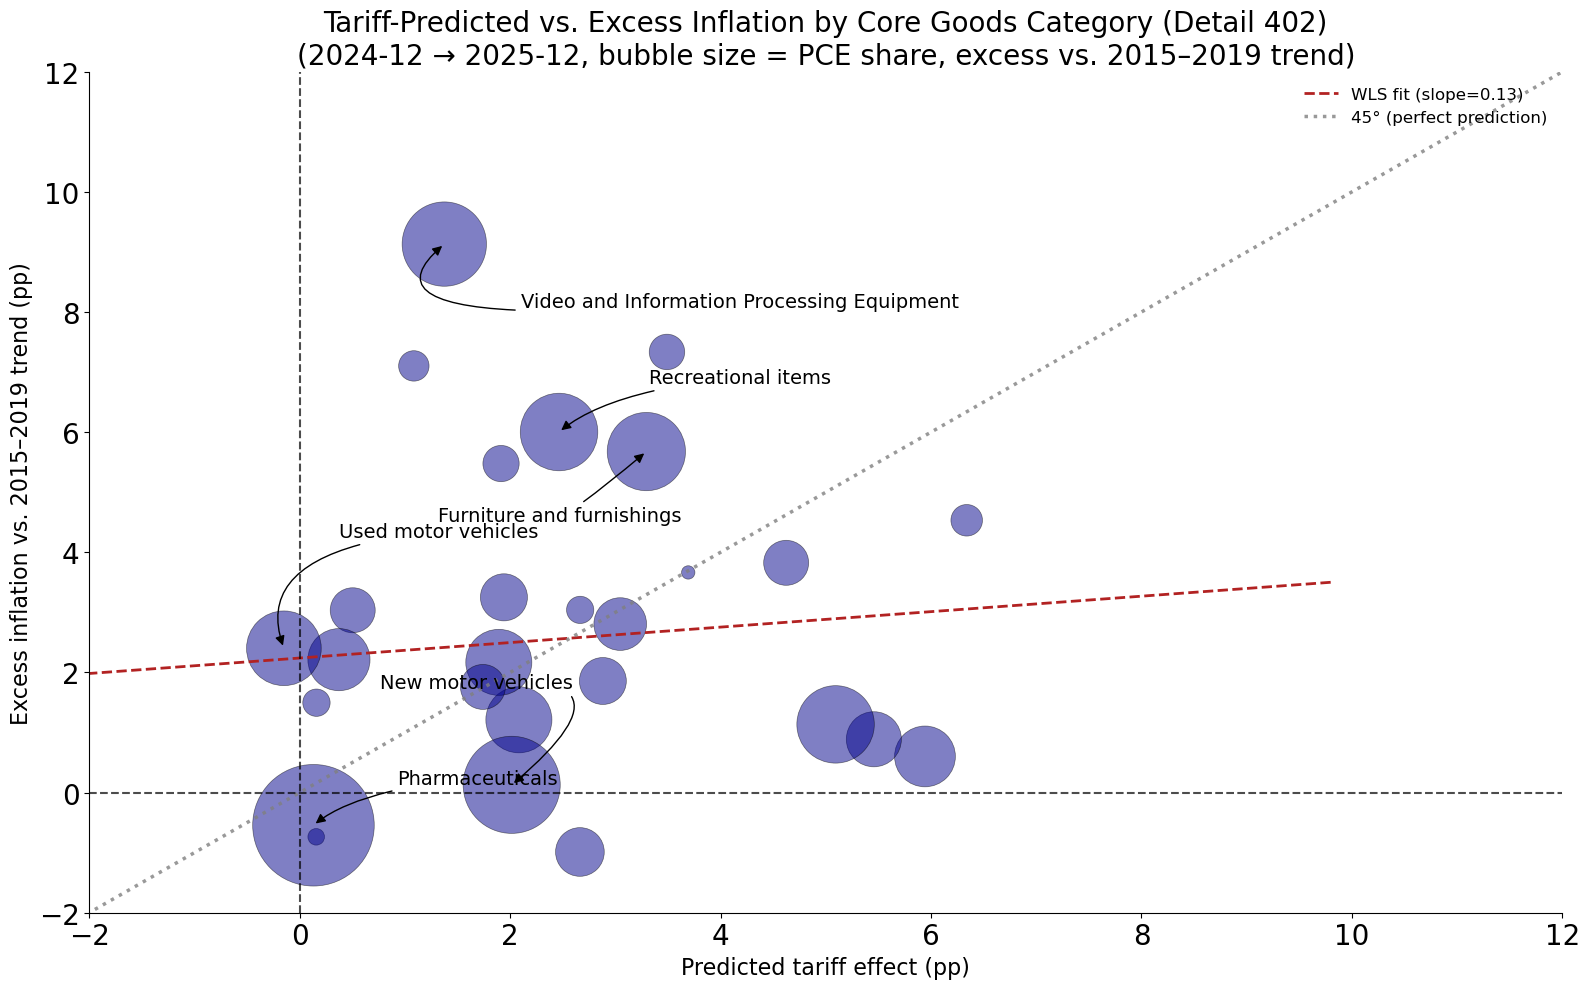

In [48]:
# ── Step 7c: Predicted tariff effect vs. excess inflation \u2014 scatter plot ──────
# Excess inflation = growth over the current window minus mean over the baseline window.
# Current window:  config.EXCESS_CURRENT_START_MONTH \u2192 config.EXCESS_CURRENT_END_MONTH
# Baseline window: config.EXCESS_BASELINE_START \u2013 config.EXCESS_BASELINE_END (inclusive).

scatter_df = pipeline.step7_excess_inflation(
    api_key               = config.BEA_KEY,
    pce_effect_df         = pce_effect_df,
    core_goods_categories = config.CORE_GOODS_CATEGORIES,
    nipa_crosswalk        = config.NIPA_CROSSWALK,
    current_start_month   = config.EXCESS_CURRENT_START_MONTH,
    current_end_month     = config.EXCESS_CURRENT_END_MONTH,
    baseline_start        = config.EXCESS_BASELINE_START,
    baseline_end          = config.EXCESS_BASELINE_END,
)

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
plot_df = scatter_df.dropna(subset=['predicted_effect', 'excess_inflation', 'pce_share'])

ax.scatter(
    plot_df['predicted_effect'] * 100,
    plot_df['excess_inflation'] * 100,
    s=plot_df['pce_share'] * 50000,
    alpha=0.5, color='darkblue', edgecolors='black', linewidths=0.5,
)

x = plot_df['predicted_effect'].values * 100
y = plot_df['excess_inflation'].values * 100
w = plot_df['pce_share'].values

wls_model  = sm.WLS(y, sm.add_constant(x), weights=w).fit()
intercept, slope = wls_model.params
print(wls_model.summary())

x_fit = np.linspace(x.min() - 3.5, x.max() + 3.5, 100)
ax.plot(x_fit, slope * x_fit + intercept,
        color='firebrick', linewidth=2, linestyle='--',
        label=f'WLS fit (slope={slope:.2f})')

# 45\u00b0 perfect-prediction line
_xy_min = min(x.min(), y.min()) - 3.05
_xy_max = max(x.max(), y.max()) + 3.05
ax.plot([_xy_min, _xy_max], [_xy_min, _xy_max],
        color="gray", linewidth=2.5, linestyle=":", alpha=0.8, label="45\u00b0 (perfect prediction)")

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)

baseline_range = f"{config.EXCESS_BASELINE_START}\u2013{config.EXCESS_BASELINE_END}"
current_window = f"{config.EXCESS_CURRENT_START_MONTH} \u2192 {config.EXCESS_CURRENT_END_MONTH}"
ax.set_title(
    f"Tariff-Predicted vs. Excess Inflation by Core Goods Category (Detail 402)\n"
    f"({current_window}, bubble size = PCE share, excess vs. {baseline_range} trend)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Excess inflation vs. {baseline_range} trend (pp)", fontsize=16)
ax.legend(fontsize=12, frameon=False, loc='upper right')
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlim(-2.0, 12.0)
ax.set_ylim(-2.0, 12.0)

# ── Annotate top 5 categories by PCE share ────────────────────────────────────
_top5 = plot_df.nlargest(5, "pce_share").reset_index(drop=True)

annotate_fontsize = 14
_offsets_top5 = [
    ( 60,  30),   # rank 0 (typically Pharmaceuticals)
    (-95,  70),   # rank 1 (typically New motor vehicles)
    ( 55, -45),   # rank 2 (typically Video/audio/info proc)
    (-150, -50),  # rank 3 (typically Recreational items)
    ( 65,  35),   # rank 4 (typically Furniture)
]
_short_labels = {
    "Pharmaceutical and other medical products": "Pharmaceuticals",
    "Video, audio, photographic, and information processing equipment and media":
        "Video and Information Processing Equipment",
}
for i, row in _top5.iterrows():
    label = _short_labels.get(row['PCE_category'], row['PCE_category'])
    ox, oy = _offsets_top5[i]
    ax.annotate(
        label,
        xy=(row['predicted_effect'] * 100, row['excess_inflation'] * 100),
        xycoords="data",
        xytext=(ox, oy),
        textcoords="offset points",
        horizontalalignment="left",
        arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
        fontsize=annotate_fontsize,
    )

# ── Annotate used motor vehicles ─────────────────────────────────────────────
_used_rows = plot_df[plot_df['PCE_category'].str.contains('sed', case=False, na=False)]
if len(_used_rows) > 0:
    _used_row = _used_rows.iloc[0]
    ax.annotate(
        "Used motor vehicles",
        xy=(_used_row['predicted_effect'] * 100, _used_row['excess_inflation'] * 100),
        xycoords="data",
        xytext=(40, 80),
        textcoords="offset points",
        horizontalalignment="left",
        arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
        fontsize=annotate_fontsize,
    )

plt.tight_layout()
plt.savefig("../figures/tariff_vs_excess_inflation_detail.png", bbox_inches="tight", dpi=150)
plt.show()

In [32]:
# ── Final Summary 1: Counterfactual snapshot + coverage diagnostics ───────────
if "result" not in globals() or not isinstance(result, dict):
    raise ValueError(
        "`result` is not available. Run the monthly counterfactual cell first."
    )

def _fmt_pct(v):
    return "nan" if pd.isna(v) else f"{v * 100:.2f}%"

print("Final Summary 1: Counterfactual + coverage  (DETAIL 402-commodity pipeline)")
print("-" * 72)
print(f"Pipeline                   : Detail ({config.DETAIL_IO_YEAR}, 402 commodities)")
print(f"Tariff month               : {config.TARIFF_CURRENT_MONTH}")
print(f"Markup assumption          : {config.MARKUP_ASSUMPTION}")
print(f"Actual inflation           : {_fmt_pct(result.get('actual_inflation', float('nan')))}")
print(f"No-tariff counterfactual   : {_fmt_pct(result.get('counterfactual_inflation', float('nan')))}")
print(f"Tariff contribution        : {_fmt_pct(result.get('tariff_contribution', float('nan')))}")
print(f"Core goods tariff effect   : {_fmt_pct(result.get('core_goods_effect', float('nan')))}")
print(f"Core goods share           : {_fmt_pct(result.get('core_goods_share', float('nan')))}")
print(f"Modeled PCE coverage       : {_fmt_pct(result.get('modeled_pce_coverage', float('nan')))}")
print(f"Core-weight coverage       : {_fmt_pct(result.get('core_weight_coverage', float('nan')))}")
missing = result.get("missing_core_categories", [])
print("Missing core categories    : " + (", ".join(missing) if missing else "None"))

Final Summary 1: Counterfactual + coverage  (DETAIL 402-commodity pipeline)
------------------------------------------------------------------------
Pipeline                   : Detail (2017, 402 commodities)
Tariff month               : 2025-12
Markup assumption          : constant_dollar
Actual inflation           : 3.01%
No-tariff counterfactual   : 2.69%
Tariff contribution        : 0.31%
Core goods tariff effect   : 2.17%
Core goods share           : 14.43%
Modeled PCE coverage       : 14.43%
Core-weight coverage       : 66.32%
Missing core categories    : None


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.005
Model:                            WLS   Adj. R-squared:                 -0.039
Method:                 Least Squares   F-statistic:                    0.1051
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.749
Time:                        17:16:38   Log-Likelihood:                -67.892
No. Observations:                  25   AIC:                             139.8
Df Residuals:                      23   BIC:                             142.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5443      1.013      2.512      0.0

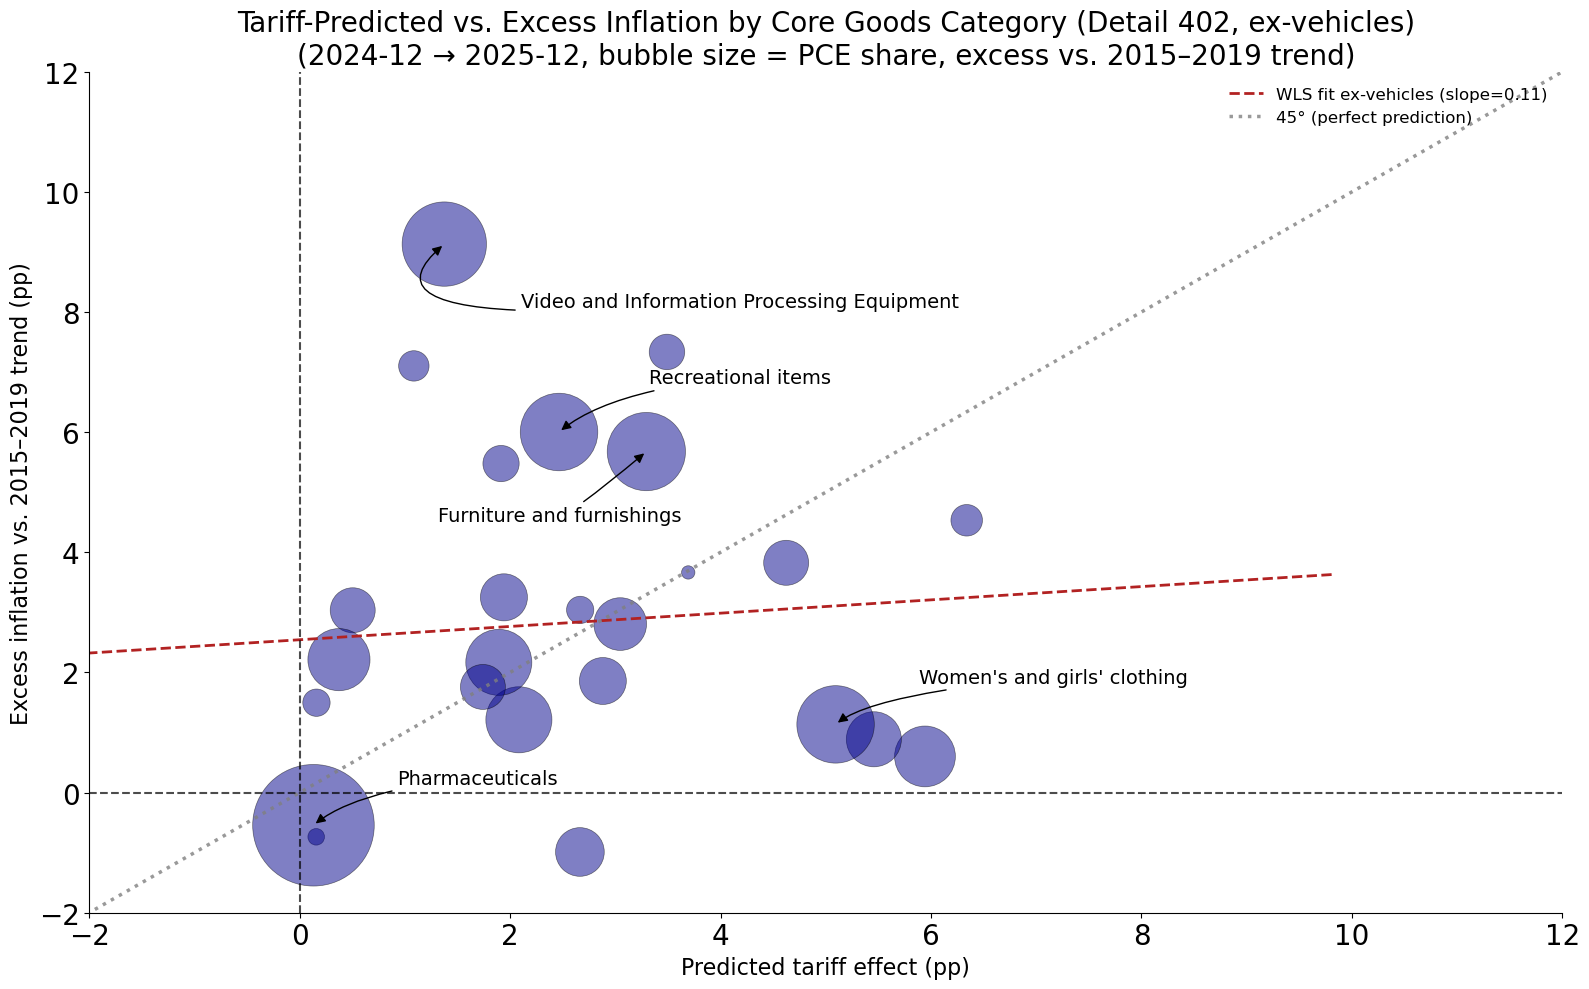

In [33]:
# ── Step 7c (ex-vehicles): Predicted tariff effect vs. excess inflation ───────
# Same as Step 7c but excludes "New motor vehicles" from both the scatter and
# the WLS regression fit.

VEHICLE_CATEGORIES = ["New motor vehicles", "Net purchases of used motor vehicles"]

plot_df_exveh = scatter_df[
    ~scatter_df["PCE_category"].isin(VEHICLE_CATEGORIES)
].dropna(subset=["predicted_effect", "excess_inflation", "pce_share"])

fig, ax = plt.subplots(figsize=(16, 10))

ax.scatter(
    plot_df_exveh["predicted_effect"] * 100,
    plot_df_exveh["excess_inflation"] * 100,
    s=plot_df_exveh["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

x_ev = plot_df_exveh["predicted_effect"].values * 100
y_ev = plot_df_exveh["excess_inflation"].values * 100
w_ev = plot_df_exveh["pce_share"].values

wls_ev = sm.WLS(y_ev, sm.add_constant(x_ev), weights=w_ev).fit()
intercept_ev, slope_ev = wls_ev.params
print(wls_ev.summary())

x_fit_ev = np.linspace(x_ev.min() - 3.5, x_ev.max() + 3.5, 100)
ax.plot(x_fit_ev, slope_ev * x_fit_ev + intercept_ev,
        color="firebrick", linewidth=2, linestyle="--",
        label=f"WLS fit ex-vehicles (slope={slope_ev:.2f})")

_xy_min = min(x_ev.min(), y_ev.min()) - 3.05
_xy_max = max(x_ev.max(), y_ev.max()) + 3.05
ax.plot([_xy_min, _xy_max], [_xy_min, _xy_max],
        color="gray", linewidth=2.5, linestyle=":", alpha=0.8, label="45° (perfect prediction)")

ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

baseline_range = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
current_window = f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"
ax.set_title(
    f"Tariff-Predicted vs. Excess Inflation by Core Goods Category (Detail 402, ex-vehicles)\n"
    f"({current_window}, bubble size = PCE share, excess vs. {baseline_range} trend)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Excess inflation vs. {baseline_range} trend (pp)", fontsize=16)
ax.legend(fontsize=12, frameon=False, loc="upper right")
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlim(-2.0, 12.0)
ax.set_ylim(-2.0, 12.0)

# ── Annotate top 5 categories by PCE share (ex-vehicles) ─────────────────────
_top5_ev = plot_df_exveh.nlargest(5, "pce_share").reset_index(drop=True)

_offsets_top5_ev = [
    ( 60,  30),
    ( 55, -45),
    (-150, -50),
    ( 65,  35),
    ( 60,  30),
]
_short_labels = {
    "Pharmaceutical and other medical products": "Pharmaceuticals",
    "Video, audio, photographic, and information processing equipment and media":
        "Video and Information Processing Equipment",
}
for i, row in _top5_ev.iterrows():
    label = _short_labels.get(row["PCE_category"], row["PCE_category"])
    ox, oy = _offsets_top5_ev[i] if i < len(_offsets_top5_ev) else (60, 30)
    ax.annotate(
        label,
        xy=(row["predicted_effect"] * 100, row["excess_inflation"] * 100),
        xycoords="data",
        xytext=(ox, oy),
        textcoords="offset points",
        horizontalalignment="left",
        arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
        fontsize=annotate_fontsize,
    )

plt.tight_layout()
plt.savefig("../figures/tariff_vs_excess_inflation_detail_exveh.png", bbox_inches="tight", dpi=150)
plt.show()


In [34]:

# ── Decomposition: share of core goods inflation by sub-component ──────────────
# Set the window start and end months here (format "YYYY-MM").
# Examples:
#   Dec-over-Dec:  _decomp_base = f"{current_year - 1}-12"  _decomp_curr = config.TARIFF_CURRENT_MONTH
#   Calendar year: _decomp_base = f"{current_year - 1}-01"  _decomp_curr = f"{current_year}-12"
#   Custom window: _decomp_base = "2024-06"                 _decomp_curr = "2025-12"

current_year = int(config.TARIFF_CURRENT_MONTH[:4])
_decomp_base = f"{current_year - 1}-12"    # ← change start month here
_decomp_curr = config.TARIFF_CURRENT_MONTH  # ← change end month here

# ── Build monthly price-wide table from pce_monthly ──────────────────────────
_bea_names = scatter_df["bea_name"].dropna().tolist()
_pm = pce_monthly[pce_monthly["LineDescription"].isin(_bea_names)].copy()
_pm["month"] = _pm["TimePeriod"].str.replace("M", "-", regex=False)
_price_wide_m = _pm.pivot(index="LineDescription", columns="month", values="DataValue")

# ── Compute inflation for each category over the chosen window ────────────────
_decomp = scatter_df[["PCE_category", "bea_name", "pce_share"]].copy()
_decomp = _decomp.dropna(subset=["bea_name", "pce_share"])

_decomp["p_base"] = _decomp["bea_name"].map(_price_wide_m[_decomp_base])
_decomp["p_curr"] = _decomp["bea_name"].map(_price_wide_m[_decomp_curr])
_decomp = _decomp.dropna(subset=["p_base", "p_curr"])

# ── n_months for annualization ────────────────────────────────────────────────
_db_yr, _db_mo = int(_decomp_base[:4]), int(_decomp_base[5:])
_dc_yr, _dc_mo = int(_decomp_curr[:4]), int(_decomp_curr[5:])
_n = (_dc_yr - _db_yr) * 12 + (_dc_mo - _db_mo)

_decomp["inflation_cumul"] = _decomp["p_curr"] / _decomp["p_base"] - 1
_decomp["inflation_ann"]   = (_decomp["p_curr"] / _decomp["p_base"]) ** (12 / _n) - 1

# ── Re-normalize weights to sum to 1 within the matched categories ────────────
_decomp["weight"] = _decomp["pce_share"] / _decomp["pce_share"].sum()

# ── Contributions ─────────────────────────────────────────────────────────────
_decomp["contrib_cumul_pp"] = _decomp["weight"] * _decomp["inflation_cumul"] * 100
_decomp["contrib_ann_pp"]   = _decomp["weight"] * _decomp["inflation_ann"]   * 100

_total_cumul = _decomp["contrib_cumul_pp"].sum()
_total_ann   = _decomp["contrib_ann_pp"].sum()

_decomp["share_cumul"] = _decomp["contrib_cumul_pp"] / _total_cumul * 100
_decomp["share_ann"]   = _decomp["contrib_ann_pp"]   / _total_ann   * 100

# ── Print ──────────────────────────────────────────────────────────────────────
print(f"Window: {_decomp_base} → {_decomp_curr}  ({_n} months)")
print(f"Implied core goods cumulative inflation:  {_total_cumul:.2f} pp")
print(f"Implied core goods annualized inflation:  {_total_ann:.2f} pp\n")

_out = (
    _decomp[["PCE_category", "weight", "inflation_cumul", "contrib_cumul_pp",
             "share_cumul", "inflation_ann", "contrib_ann_pp", "share_ann"]]
    .assign(
        weight          = lambda d: d["weight"]          * 100,
        inflation_cumul = lambda d: d["inflation_cumul"] * 100,
        inflation_ann   = lambda d: d["inflation_ann"]   * 100,
    )
    .sort_values("contrib_cumul_pp", ascending=False)
    .rename(columns={
        "weight":           "PCE wt (%)",
        "inflation_cumul":  "Cumul. infl. (pp)",
        "contrib_cumul_pp": "Contrib. cumul (pp)",
        "share_cumul":      "Share cumul (%)",
        "inflation_ann":    "Ann. infl. (pp)",
        "contrib_ann_pp":   "Contrib. ann (pp)",
        "share_ann":        "Share ann (%)",
    })
    .reset_index(drop=True)
)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 140)
display(_out)


Window: 2024-12 → 2025-12  (12 months)
Implied core goods cumulative inflation:  1.95 pp
Implied core goods annualized inflation:  1.95 pp



,PCE_category,PCE wt (%),Cumul. infl. (pp),Contrib. cumul (pp),Share cumul (%),Ann. infl. (pp),Contrib. ann (pp),Share ann (%)
0,Tobacco,4.00,6.75,0.27,13.88,6.75,0.27,13.88
1,Furniture and furnishings,6.35,4.18,0.27,13.63,4.18,0.27,13.63
2,Pharmaceutical and other medical products,15.33,1.59,0.24,12.50,1.59,0.24,12.50
3,"Video, audio, photographic, and information pr...",7.38,2.71,0.20,10.27,2.71,0.20,10.27
4,Recreational items,6.23,2.76,0.17,8.83,2.76,0.17,8.83
5,"Magazines, newspapers, and stationery",2.10,5.31,0.11,5.73,5.31,0.11,5.73
6,Motor vehicle parts and accessories,2.88,3.57,0.10,5.27,3.57,0.10,5.27
7,Net purchases of used motor vehicles,5.78,1.62,0.09,4.81,1.62,0.09,4.81
8,Jewelry and watches,2.30,3.95,0.09,4.66,3.95,0.09,4.66
9,Personal care products,4.52,1.82,0.08,4.22,1.82,0.08,4.22


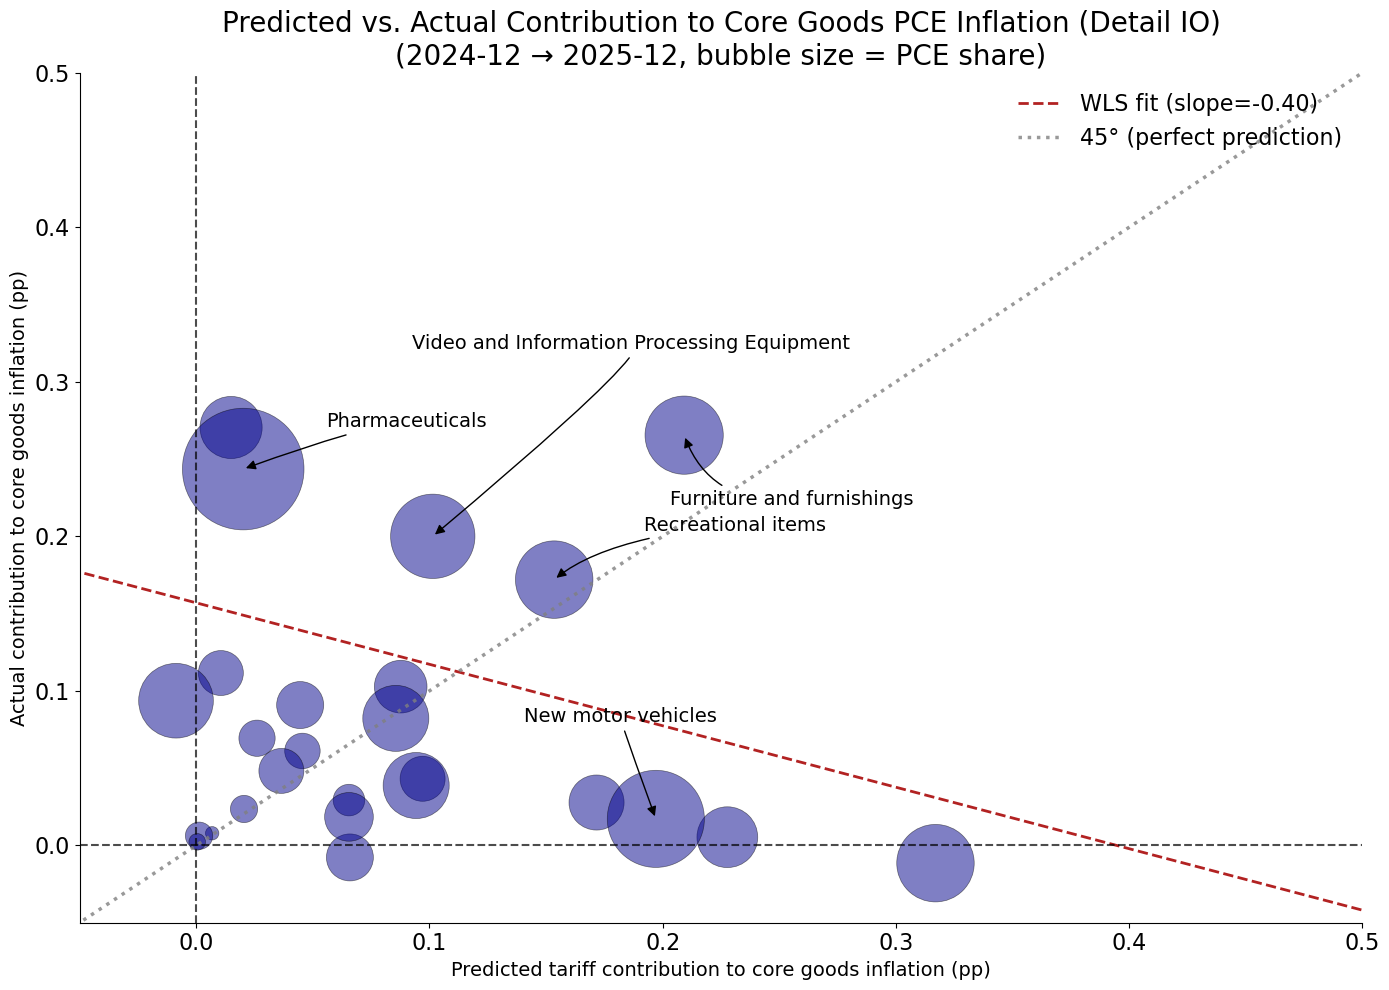

In [49]:

# ── Predicted contribution vs. actual contribution — same-units scatter ────────
# X: predicted tariff contribution to core goods PCE (weight × predicted_effect, pp)
# Y: actual cumulative contribution to core goods PCE (weight × inflation_cumul, pp)
# Both axes in percentage-point contributions, so the 45° line = perfect prediction.

# Merge predicted_effect onto the decomp frame
_dplot = _decomp.merge(
    scatter_df[["PCE_category", "predicted_effect"]],
    on="PCE_category", how="left"
).dropna(subset=["predicted_effect", "contrib_cumul_pp", "pce_share"])

_dplot2 = _dplot.copy()
_dplot2["predicted_contrib_pp"] = _dplot2["weight"] * _dplot2["predicted_effect"] * 100

_d2 = _dplot2.dropna(subset=["predicted_contrib_pp", "contrib_cumul_pp", "pce_share"])

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(
    _d2["predicted_contrib_pp"],
    _d2["contrib_cumul_pp"],
    s=_d2["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

_x2 = _d2["predicted_contrib_pp"].values
_y2 = _d2["contrib_cumul_pp"].values
_w2 = _d2["pce_share"].values
_wls2 = sm.WLS(_y2, sm.add_constant(_x2), weights=_w2).fit()
_int2, _sl2 = _wls2.params
_xf2 = np.linspace(_x2.min() - 0.25, _x2.max() + 0.25, 100)
ax.plot(_xf2, _sl2 * _xf2 + _int2, color="firebrick", linewidth=2, linestyle="--",
        label=f"WLS fit (slope={_sl2:.2f})")

# 45° perfect-prediction line
_xy_min = min(_x2.min(), _y2.min()) - 0.25
_xy_max = max(_x2.max(), _y2.max()) + 0.25
ax.plot([_xy_min, _xy_max], [_xy_min, _xy_max],
        color="gray", linewidth=2.5, linestyle=":", alpha=0.8, label="45° (perfect prediction)")

ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

ax.set_title(
    f"Predicted vs. Actual Contribution to Core Goods PCE Inflation (Detail IO)\n"
    f"({_decomp_base} → {_decomp_curr}, bubble size = PCE share)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff contribution to core goods inflation (pp)", fontsize=14)
ax.set_ylabel(f"Actual contribution to core goods inflation (pp)", fontsize=14)
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.legend(fontsize=16, frameon=False, loc='upper right')

ax.set_ylim(-0.05, 0.5)
ax.set_xlim(-0.05, 0.5)

# # ── Summary box ───────────────────────────────────────────────────────────────
# ax.text(
#     0.98, 0.30,
#     f"Predicted Core goods cumulative inflation\n{_decomp_base} → {_decomp_curr}: {_total_cumul:.2f} pp",
#     transform=ax.transAxes,
#     fontsize=18,
#     verticalalignment="top",
#     horizontalalignment="right",
#     bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", linewidth=1),
# )

# ── Annotate top 5 categories by PCE share ────────────────────────────────────
_top5_2 = _d2.nlargest(5, "pce_share").reset_index(drop=True)
annotate_fontsize = 14

_short_labels = {
    "Pharmaceutical and other medical products": "Pharmaceuticals",
    "Video, audio, photographic, and information processing equipment and media":
        "Video and Information Processing Equipment",
}

ax.annotate(  # pharmaceuticals
    _short_labels.get(_top5_2.loc[0, "PCE_category"], _top5_2.loc[0, "PCE_category"]),
    xy=(_top5_2.loc[0, "predicted_contrib_pp"], _top5_2.loc[0, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(60, 30),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=20", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # new motor vehicles
    _top5_2.loc[1, "PCE_category"],
    xy=(_top5_2.loc[1, "predicted_contrib_pp"], _top5_2.loc[1, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(-95, 70),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # video & info processing equipment
    _short_labels.get(_top5_2.loc[2, "PCE_category"], _top5_2.loc[2, "PCE_category"]),
    xy=(_top5_2.loc[2, "predicted_contrib_pp"], _top5_2.loc[2, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(-15, 135),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # recreational items
    _top5_2.loc[3, "PCE_category"],
    xy=(_top5_2.loc[3, "predicted_contrib_pp"], _top5_2.loc[3, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(-10, -50),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # furniture & furnishings
    _top5_2.loc[4, "PCE_category"],
    xy=(_top5_2.loc[4, "predicted_contrib_pp"], _top5_2.loc[4, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

# # ── Annotate top 2 contributors (by actual contrib_cumul_pp, not already labeled) ───
# _already_labeled2 = set(_top5_2["PCE_category"].tolist()) | {"Pharmaceutical and other medical products",
#                                                               "Video, audio, photographic, and information processing equipment and media"}
# _top2_contrib2 = (
#     _d2[~_d2["PCE_category"].isin(_already_labeled2)]
#     .nlargest(2, "contrib_cumul_pp")
#     .reset_index(drop=True)
# )

# ax.annotate(  # top contributor (rank 1)
#     _top2_contrib2.loc[0, "PCE_category"],
#     xy=(_top2_contrib2.loc[0, "predicted_contrib_pp"], _top2_contrib2.loc[0, "contrib_cumul_pp"]),
#     xycoords="data",
#     xytext=(55, -100),
#     textcoords="offset points",
#     horizontalalignment="left",
#     arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
#     fontsize=annotate_fontsize,
# )

plt.tight_layout()
plt.savefig("../figures/tariff_vs_contribution_same_units_detail.png", bbox_inches="tight", dpi=150)
plt.show()


In [36]:
# ── Final Summary 2: Tariff accounting (long format) ─────────────────────────
if "result" not in globals() or not isinstance(result, dict):
    raise ValueError(
        "`result` is not available. Run the monthly counterfactual cell first."
    )

core_direct_pp = result.get("core_goods_effect", float("nan")) * 100
actual_pp = result.get("actual_inflation", float("nan")) * 100
no_tariff_pp = result.get("counterfactual_inflation", float("nan")) * 100
headline_implied_pp = actual_pp - no_tariff_pp

stats = delta_tariff_df["delta_tariff"].agg(["mean", "median", "std"]) * 100

assumption_label = (
    "Constant-dollar pass-through"
    if config.MARKUP_ASSUMPTION == "constant_dollar"
    else "Constant-percent pass-through"
)

def _fmt_pp(v):
    return "nan" if pd.isna(v) else f"{v:.2f} pp"

print("Final Summary 2: Tariff accounting  (DETAIL 402-commodity pipeline)")
print("-" * 72)
print(f"Assumption                         : {assumption_label}")
print(f"Tariff direct effect (core goods)  : {_fmt_pp(core_direct_pp)}")
print(f"Commodity simple avg tariff change : {_fmt_pp(float(stats['mean']))}")
print(f"Commodity median tariff change     : {_fmt_pp(float(stats['median']))}")
print(f"Commodity std dev tariff change    : {_fmt_pp(float(stats['std']))}")
print(f"Inflation with tariffs             : {_fmt_pp(actual_pp)}")
print(f"Inflation no-tariff counterfactual : {_fmt_pp(no_tariff_pp)}")
print(f"Tariff implied headline contrib.   : {_fmt_pp(headline_implied_pp)}")
print(f"Wedge (core direct - implied)      : {_fmt_pp(core_direct_pp - headline_implied_pp)}")

Final Summary 2: Tariff accounting  (DETAIL 402-commodity pipeline)
------------------------------------------------------------------------
Assumption                         : Constant-dollar pass-through
Tariff direct effect (core goods)  : 2.17 pp
Commodity simple avg tariff change : 11.43 pp
Commodity median tariff change     : 10.96 pp
Commodity std dev tariff change    : 8.38 pp
Inflation with tariffs             : 3.01 pp
Inflation no-tariff counterfactual : 2.69 pp
Tariff implied headline contrib.   : 0.31 pp
Wedge (core direct - implied)      : 1.86 pp
